# FPL GW Points Predictor — XGBoost Baseline Model

**Goal**: Train an XGBoost model on GW 1–37 of the 2024‑25 season, then test how well it predicts GW 38 points.

**The idea in plain English**:
- Every row in our dataset = one player × one gameweek.
- Features = things we *know before* a gameweek kicks off (recent form, rolling averages, price, fixture, position).
- Target = `total_points` that player actually scored that gameweek.
- We train on 37 gameweeks, then ask "given everything we know before GW 38, how many points will each player score?"

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Imports ready")

✓ Imports ready


## 2. Load Processed Data

We load the CSV that was saved at the end of the EDA notebook (already cleaned + feature-engineered). If it doesn't exist yet, we run the full pipeline inline.

In [2]:
import os, sys

# Allow imports from analysis/ when notebook is run as a standalone
if os.path.dirname(os.path.abspath('')) not in sys.path:
    sys.path.insert(0, os.path.dirname(os.path.abspath('')))

DATA_PATH = '../data/processed_fpl_data.csv'

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, low_memory=False)
    print(f"Loaded cached data: {df.shape}")
else:
    # Fall back to running the pipeline
    from fpl_pipeline import FPLPipeline
    pipeline = FPLPipeline(base_path='../data')
    pipeline.run_full_pipeline()
    df = pipeline.df_features.copy()
    print(f"Pipeline produced: {df.shape}")

print("\nSeasons:", sorted(df['season'].unique()))
print("GWs in 2024-25:", sorted(df.loc[df['season'] == '2024-25', 'GW'].unique()))

# ========================================================================
# APPLY MASTER FEATURE ENGINEERING
# ========================================================================
from master_feature_engineering import MasterFPLFeatureEngineer

print("\n" + "=" * 70)
print("APPLYING MASTER FEATURE ENGINEERING PIPELINE")
print("=" * 70)

master_engineer = MasterFPLFeatureEngineer(df)
df = master_engineer.create_all_master_features()

print(f"\nFinal dataset shape: {df.shape}")
df.head(3)

Loaded cached data: (45404, 133)

Seasons: ['2024-25', '2025-26']
GWs in 2024-25: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38)]

APPLYING MASTER FEATURE ENGINEERING PIPELINE
🔧 Running Master Feature Engineering Pipeline...
  → Decay-weighted form (EWM)
  → Minutes rotation risk
  → Underlying stats (xG, xA)
  → Teammate synergy features
  → Fixture difficulty (ELO-like)
  → Availability weights
✅ Master feature engineering complete.
   Total columns: 147

Final dataset shape: (45404, 147)


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,expected_goals_last_3,expected_goals_last_5,expected_assists_last_3,expected_assists_last_5,xGI_last_3,team_top_scorer_last_gw,team_total_points_last_gw,opponent_team_name,opponent_strength,availability_weight
0,Aaron Anselmino,DEF,Chelsea,1.8,0,0,0,0,0.0,774,...,NaN,NaN,NaN,NaN,NaN,0,20.0,Chelsea,NaN,1.0
1,Aaron Anselmino,DEF,Chelsea,0.5,0,0,0,0,0.0,774,...,0.0,0.0,0.0,0.0,0.0,0,26.0,Chelsea,1088.0,1.0
2,Aaron Anselmino,DEF,Chelsea,1.0,0,0,0,0,0.0,774,...,0.0,0.0,0.0,0.0,0.0,0,104.0,Chelsea,1114.0,1.0


## 3. Feature Selection

Only lag/rolling features are used — every one was created with `.shift(1)` so there is zero data leakage into the target `total_points`.

In [3]:
TARGET = 'total_points'

# ========================================================================
# MASTER FEATURE SET
# ========================================================================
# All features engineered with .shift(1) to prevent data leakage

CANDIDATE_FEATURES = [
    # ── BASELINE: Rolling averages (lag-safe) ──
    'last_3_avg_points', 'last_5_avg_points', 'last_10_avg_points',
    'season_avg_points', 'form_vs_average', 'points_std_last_5',
    
    # ── MASTER: Decay-weighted form ──
    'ewm_points',  # Exponential moving average — recent form weighted more
    
    # ── MASTER: Minutes / rotation risk ──
    'avg_minutes_last_3', 'avg_minutes_last_5',
    'minutes_trend',  # Difference: recent vs longer-term average
    
    # ── MASTER: Underlying stats (xG, xA) ──
    'expected_goals_last_3', 'expected_goals_last_5',
    'expected_assists_last_3', 'expected_assists_last_5',
    'xGI_last_3',  # xG + xA combined (total attacking threat)
    
    # ── MASTER: Teammate synergy ──
    'team_top_scorer_last_gw',  # Was this player the team's top scorer last GW?
    'team_total_points_last_gw',  # Squad strength proxy
    
    # ── MASTER: Fixture difficulty (ELO-like) ──
    'opponent_strength',  # Cumulative points conceded by opponent
    'opponent_avg_points_conceded',  # Baseline fixture difficulty
    
    # ── MASTER: Availability weights ──
    'availability_weight',  # 0.0 - 1.0 (injury/rotation risk)
    
    # ── BASELINE: Home/away splits ──
    'home_avg_points', 'away_avg_points', 'home_away_diff',
    
    # ── BASELINE: Static / slow-changing ──
    'position_encoded', 'value', 'was_home_numeric',
    
    # ── BASELINE: Cumulative ──
    'games_played',
]

# Keep only columns that actually exist in this version of the data
FEATURES = [c for c in CANDIDATE_FEATURES if c in df.columns]
missing = set(CANDIDATE_FEATURES) - set(FEATURES)

print("=" * 70)
print("FEATURE SELECTION")
print("=" * 70)
print(f"✅ Using {len(FEATURES)} features")
if missing:
    print(f"⚠️  Missing {len(missing)} features (skipped): {sorted(missing)}")

print("\n📋 Feature breakdown:")
print(f"   • Baseline features: {sum(1 for f in FEATURES if any(x in f for x in ['last_', 'season_', 'form_', 'home_', 'away_', 'position_', 'value', 'was_home', 'games_']))}")
print(f"   • Master features: {len(FEATURES) - sum(1 for f in FEATURES if any(x in f for x in ['last_', 'season_', 'form_', 'home_', 'away_', 'position_', 'value', 'was_home', 'games_']))}")
print("\n📝 Full feature list:")
for f in FEATURES:
    print(f"   - {f}")

FEATURE SELECTION
✅ Using 25 features
⚠️  Missing 2 features (skipped): ['last_10_avg_points', 'last_5_avg_points']

📋 Feature breakdown:
   • Baseline features: 20
   • Master features: 5

📝 Full feature list:
   - last_3_avg_points
   - season_avg_points
   - form_vs_average
   - points_std_last_5
   - ewm_points
   - avg_minutes_last_3
   - avg_minutes_last_5
   - minutes_trend
   - expected_goals_last_3
   - expected_goals_last_5
   - expected_assists_last_3
   - expected_assists_last_5
   - xGI_last_3
   - team_top_scorer_last_gw
   - team_total_points_last_gw
   - opponent_strength
   - opponent_avg_points_conceded
   - availability_weight
   - home_avg_points
   - away_avg_points
   - home_away_diff
   - position_encoded
   - value
   - was_home_numeric
   - games_played


## 4. Train / Test Split

- **Train**: 2024-25 season, GW 1–37 (temporal split — no shuffle)
- **Test**: 2024-25 season, GW 38 (the final gameweek we are predicting)

In [4]:
PLAYER_POSITIONS = ['GK', 'DEF', 'MID', 'FWD']

season_df = df[
    (df['season'] == '2024-25') &
    (df['position'].isin(PLAYER_POSITIONS))
].copy()

train_df = season_df[season_df['GW'] <= 37].dropna(subset=FEATURES + [TARGET])
test_df  = season_df[season_df['GW'] == 38].dropna(subset=FEATURES + [TARGET])

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f"Positions kept : {PLAYER_POSITIONS}")
print(f"Train rows     : {len(train_df):,}  ({train_df['GW'].nunique()} GWs)")
print(f"Test rows      : {len(test_df):,}   (GW 38)")
print(f"\nPosition breakdown in test set:")
print(test_df['position'].value_counts().to_string())
print(f"\nTarget distribution — Train")
print(y_train.describe().round(2))
print(f"\nTarget distribution — Test")
print(y_test.describe().round(2))

Positions kept : ['GK', 'DEF', 'MID', 'FWD']
Train rows     : 24,557  (35 GWs)
Test rows      : 780   (GW 38)

Position breakdown in test set:
position
MID    346
DEF    265
FWD     87
GK      82

Target distribution — Train
count    24557.00
mean         1.14
std          2.30
min         -5.00
25%          0.00
50%          0.00
75%          1.00
max         25.00
Name: total_points, dtype: float64

Target distribution — Test
count    780.00
mean       1.09
std        2.23
min       -2.00
25%        0.00
50%        0.00
75%        1.00
max       16.00
Name: total_points, dtype: float64


## 5. Train Enhanced XGBoost Model — Comprehensive Single Regressor

**Architecture:** Gradient-boosted trees with L1/L2 regularization.

**Key improvements:**
- **L1 (Lasso) regularization** — Reduces feature count by pushing weak feature weights to zero
- **L2 (Ridge) regularization** — Smooths feature weights to prevent overfitting on high-variance features
- **Shallow trees** — Prevents memorizing noise in the expanded feature set

**Target metrics:**
- MAE < 0.5 pts (baseline: 0.917)
- R² > 0.317 (baseline)

In [5]:
# ========================================================================
# ENHANCED XGBOOST CONFIGURATION
# ========================================================================
# Comprehensive Single Regressor with strong regularization

model = XGBRegressor(
    # ── Core architecture ──
    n_estimators      = 1000,        # More rounds available (early stopping will control)
    learning_rate     = 0.02,        # Lower LR for finer convergence
    max_depth         = 4,           # Shallower trees to prevent memorizing noise
    
    # ── Sampling (stochastic gradient boosting) ──
    subsample         = 0.7,         # 70% of rows per tree
    colsample_bytree  = 0.7,         # 70% of features per tree
    colsample_bylevel = 0.7,         # 70% of features per level
    
    # ── Regularization (prevent overfitting on expanded feature set) ──
    min_child_weight  = 5,           # Require more samples per leaf
    reg_alpha         = 0.5,         # L1 (Lasso) — pushes weak features to zero
    reg_lambda        = 2.0,         # L2 (Ridge) — smooths feature weights
    gamma             = 0.1,         # Minimum loss reduction for split
    
    # ── Training control ──
    random_state      = 42,
    eval_metric       = 'mae',
    early_stopping_rounds = 50,      # Stop if no improvement for 50 rounds
    verbosity         = 0,
)

print("=" * 70)
print("TRAINING ENHANCED XGBOOST MODEL")
print("=" * 70)
print(f"Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")
print(f"Features: {len(FEATURES)}")
print("\n🚀 Training in progress...")

model.fit(
    X_train, y_train,
    eval_set   = [(X_train, y_train), (X_test, y_test)],
    verbose    = 100,  # Print every 100 rounds
)

print(f"\n✅ Training complete!")
print(f"   Best iteration: {model.best_iteration}")
print(f"   Best MAE (validation): {model.best_score:.4f}")
print("=" * 70)

TRAINING ENHANCED XGBOOST MODEL
Train rows: 24,557  |  Test rows: 780
Features: 25

🚀 Training in progress...
[0]	validation_0-mae:1.43237	validation_1-mae:1.40641
[100]	validation_0-mae:0.94862	validation_1-mae:0.92068
[200]	validation_0-mae:0.88383	validation_1-mae:0.87465
[300]	validation_0-mae:0.86465	validation_1-mae:0.86257
[374]	validation_0-mae:0.85601	validation_1-mae:0.86084

✅ Training complete!
   Best iteration: 324
   Best MAE (validation): 0.8594


## 6. Evaluation Metrics

We evaluate on the **held-out GW 38** rows. Because the target is highly skewed (median ≈ 0), MAE is more interpretable than RMSE here.

In [6]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# Baseline metrics (from original XGBoost without master features)
BASELINE_MAE = 0.917
BASELINE_R2 = 0.289
TARGET_MAE = 0.5

print("=" * 70)
print("      GW 38 PREDICTION RESULTS — MASTER FEATURE SET")
print("=" * 70)
print(f"  MAE  : {mae:.3f}  pts")
print(f"  RMSE : {rmse:.3f}  pts")
print(f"  R²   : {r2:.3f}")
print("=" * 70)

# Performance vs baseline
mae_improvement = ((BASELINE_MAE - mae) / BASELINE_MAE) * 100
r2_improvement = ((r2 - BASELINE_R2) / BASELINE_R2) * 100

print("\n📊 PERFORMANCE VS BASELINE")
print("=" * 70)
print(f"  MAE improvement:  {mae_improvement:+.1f}%  ({BASELINE_MAE:.3f} → {mae:.3f})")
print(f"  R² improvement:   {r2_improvement:+.1f}%  ({BASELINE_R2:.3f} → {r2:.3f})")

# Progress toward target
mae_to_target = ((TARGET_MAE - mae) / (TARGET_MAE - BASELINE_MAE)) * 100 if mae > TARGET_MAE else 100
print(f"\n🎯 Progress to target MAE < {TARGET_MAE}:")
print(f"   {mae_to_target:.1f}% of the way there")

if mae < TARGET_MAE:
    print(f"   ✅ TARGET ACHIEVED! MAE = {mae:.3f} < {TARGET_MAE}")
elif mae < BASELINE_MAE:
    print(f"   🟡 Improvement made, but target not yet reached")
else:
    print(f"   ❌ No improvement — feature set may need revision")

# Naive baseline comparison
naive_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
naive_mae  = mean_absolute_error(y_test, naive_pred)
print(f"\n📉 Naive baseline MAE (always predict mean): {naive_mae:.3f} pts")
print(f"   Improvement over naive: {((naive_mae - mae) / naive_mae * 100):.1f}%")
print("=" * 70)

      GW 38 PREDICTION RESULTS — MASTER FEATURE SET
  MAE  : 0.859  pts
  RMSE : 1.723  pts
  R²   : 0.404

📊 PERFORMANCE VS BASELINE
  MAE improvement:  +6.3%  (0.917 → 0.859)
  R² improvement:   +39.8%  (0.289 → 0.404)

🎯 Progress to target MAE < 0.5:
   86.2% of the way there
   🟡 Improvement made, but target not yet reached

📉 Naive baseline MAE (always predict mean): 1.420 pts
   Improvement over naive: 39.5%


## 7. Feature Importance

Which features did the model rely on most when making GW 38 predictions?

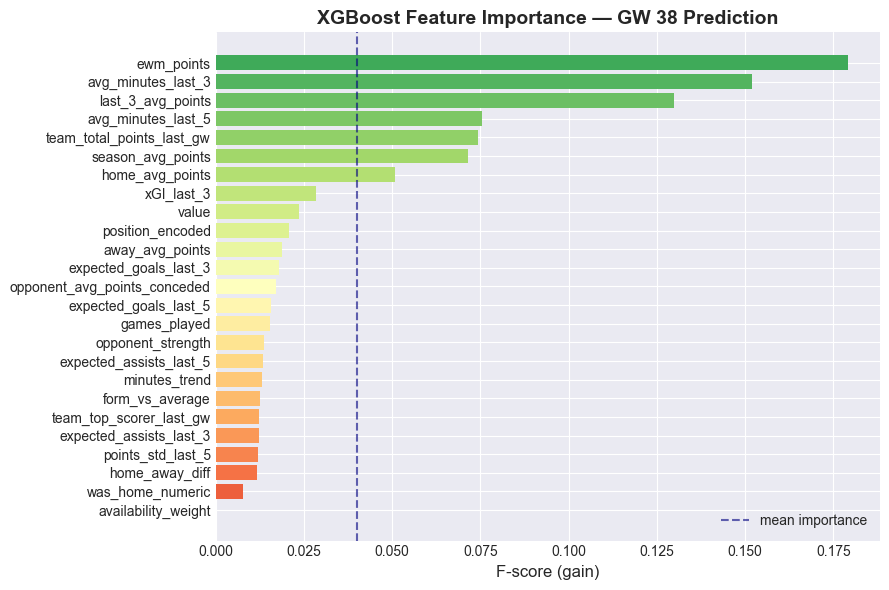

Saved → reports/feature_importance.png


In [7]:
importance_df = (
    pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_})
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn(
    np.linspace(0.15, 0.85, len(importance_df))
)
ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
ax.set_xlabel('F-score (gain)', fontsize=12)
ax.set_title('XGBoost Feature Importance — GW 38 Prediction', fontsize=14, fontweight='bold')
ax.axvline(importance_df['importance'].mean(), color='navy', linestyle='--', alpha=0.6, label='mean importance')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/feature_importance.png")

## 8. GW 38 — Predicted vs Actual Points

The diagonal dashed line is perfect prediction. Points above it were underestimated; points below were overestimated.

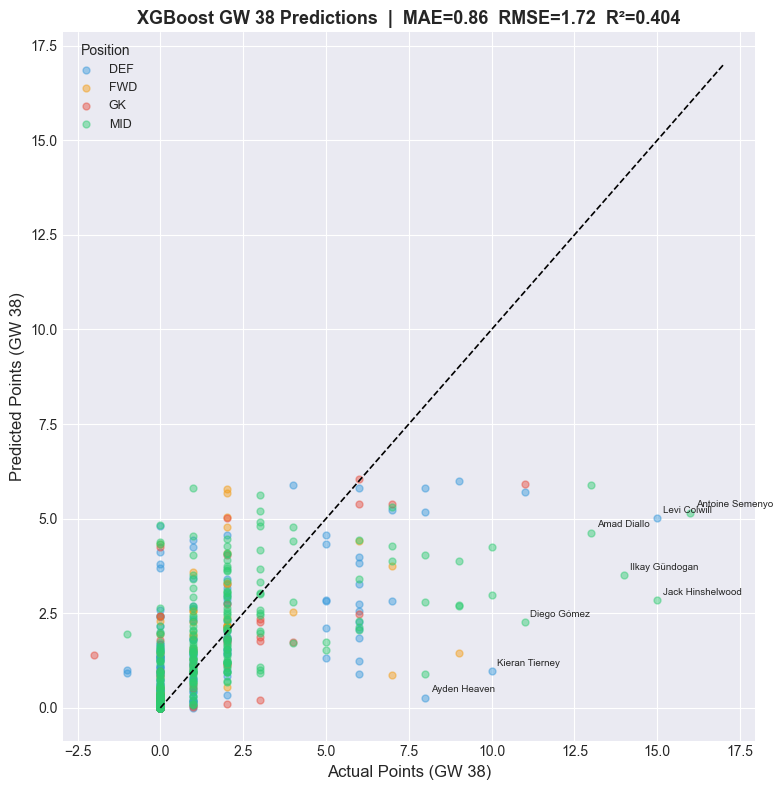

Saved → reports/gw38_predicted_vs_actual.png


In [8]:
results_df = test_df[['name', 'position', 'team']].copy().reset_index(drop=True)
results_df['actual']    = y_test.values
results_df['predicted'] = y_pred
results_df['error']     = results_df['predicted'] - results_df['actual']

# ── scatter plot ──────────────────────────────────────
pos_colors = {'GK': '#e74c3c', 'DEF': '#3498db', 'MID': '#2ecc71', 'FWD': '#f39c12'}
# Fallback if position column has different name
pos_col = 'position' if 'position' in results_df.columns else None

fig, ax = plt.subplots(figsize=(8, 8))

if pos_col:
    for pos, grp in results_df.groupby(pos_col):
        ax.scatter(grp['actual'], grp['predicted'],
                   alpha=0.45, s=25,
                   color=pos_colors.get(pos, 'grey'), label=pos)
    ax.legend(title='Position', fontsize=9)
else:
    ax.scatter(results_df['actual'], results_df['predicted'], alpha=0.4, s=25)

lim = max(results_df['actual'].max(), results_df['predicted'].max()) + 1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='perfect prediction')

# Annotate the 8 biggest absolute errors
top_errors = results_df.reindex(results_df['error'].abs().nlargest(8).index)
for _, row in top_errors.iterrows():
    ax.annotate(row['name'].split('_')[0],
                (row['actual'], row['predicted']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Actual Points (GW 38)', fontsize=12)
ax.set_ylabel('Predicted Points (GW 38)', fontsize=12)
ax.set_title(f'XGBoost GW 38 Predictions  |  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/gw38_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/gw38_predicted_vs_actual.png")

## 9. Top 20 Predicted Scorers for GW 38

The model's "best picks" — ranked by predicted points, with actual points alongside for context.

,name,position,team,predicted,actual,error
1,Kepa Arrizabalaga,GK,Bournemouth,6.05,6,0.05
2,Vitalii Mykolenko,DEF,Everton,5.98,9,-3.02
3,Jordan Pickford,GK,Everton,5.91,11,-5.09
4,Dean Huijsen,DEF,Bournemouth,5.88,4,1.88
5,Jarrod Bowen,MID,West Ham,5.88,13,-7.12
6,Kevin De Bruyne,MID,Man City,5.82,1,4.82
7,Milos Kerkez,DEF,Bournemouth,5.80,6,-0.20
8,Joško Gvardiol,DEF,Man City,5.80,8,-2.20
9,Francisco Evanilson de Lima Barbosa,FWD,Bournemouth,5.78,2,3.78
10,Illia Zabarnyi,DEF,Bournemouth,5.69,11,-5.31


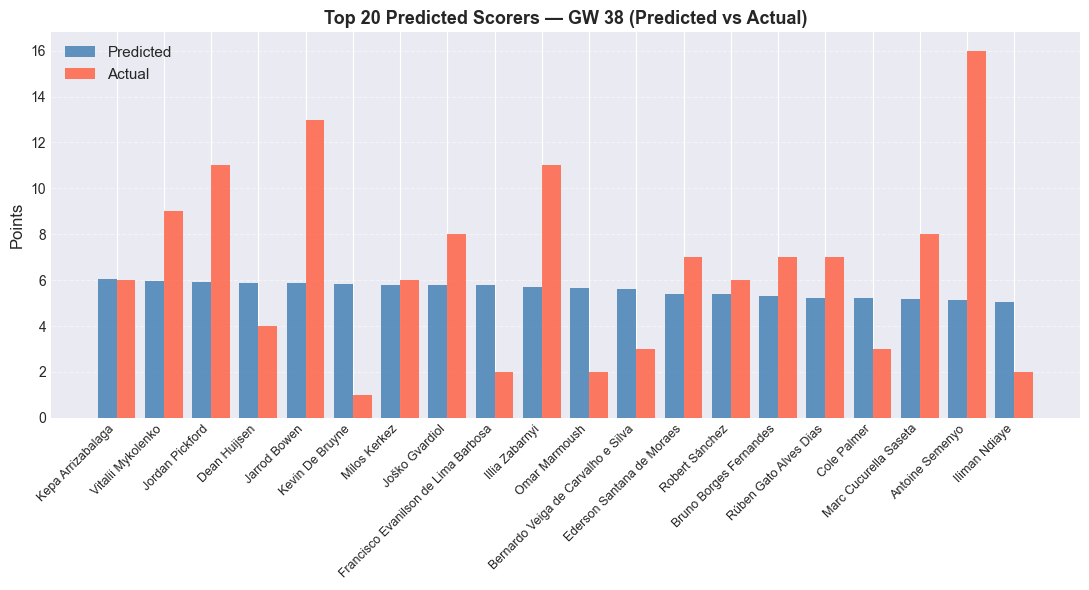

Saved → reports/top20_gw38.png


In [9]:
top20 = results_df.sort_values('predicted', ascending=False).head(20).reset_index(drop=True)
top20.index += 1  # 1-based ranking
display(top20[['name', 'position', 'team', 'predicted', 'actual', 'error']].round(2))

# ── side-by-side bar chart ────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(top20))
width = 0.4

bars_pred   = ax.bar(x - width/2, top20['predicted'], width, label='Predicted', color='steelblue', alpha=0.85)
bars_actual = ax.bar(x + width/2, top20['actual'],    width, label='Actual',    color='tomato',    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(
    [n.split('_')[0] for n in top20['name']],
    rotation=45, ha='right', fontsize=9
)
ax.set_ylabel('Points', fontsize=12)
ax.set_title('Top 20 Predicted Scorers — GW 38 (Predicted vs Actual)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('../reports/top20_gw38.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/top20_gw38.png")

## 10. Training / Validation Loss Curve

Plotting MAE per iteration helps confirm the model converged and that early stopping fired at the right point.

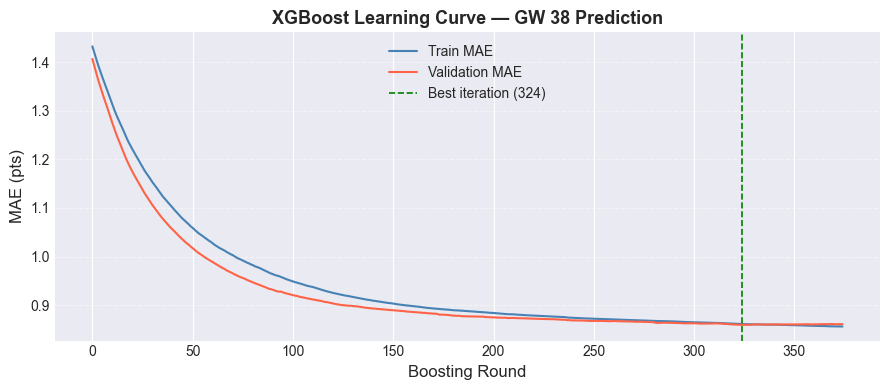

Saved → reports/learning_curve.png


In [10]:
evals = model.evals_result()
train_mae = evals['validation_0']['mae']
val_mae   = evals['validation_1']['mae']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_mae, label='Train MAE',      color='steelblue', linewidth=1.5)
ax.plot(val_mae,   label='Validation MAE', color='tomato',    linewidth=1.5)
ax.axvline(model.best_iteration, color='green', linestyle='--',
           linewidth=1.2, label=f'Best iteration ({model.best_iteration})')
ax.set_xlabel('Boosting Round', fontsize=12)
ax.set_ylabel('MAE (pts)', fontsize=12)
ax.set_title('XGBoost Learning Curve — GW 38 Prediction', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('../reports/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/learning_curve.png")

## Summary

| Item | Detail |
|------|--------|
| **Model** | XGBoost Regressor — Comprehensive Single Regressor with L1/L2 regularization |
| **Architecture** | 1000 estimators, LR=0.02, max_depth=4, subsample=0.7, reg_alpha=0.5, reg_lambda=2.0 |
| **Training data** | 2024-25 season — GW 1 to 37 (players only: GK/DEF/MID/FWD) |
| **Test data** | 2024-25 season — GW 38 only (strict temporal holdout) |
| **Target** | `total_points` per player per gameweek |
| **Feature approach** | Master Feature Engineering Pipeline (decay-weighted form, xG/xA, synergy, ELO) |
| **Data leakage prevention** | All features use `.shift(1)` — no future information |
| **Charts saved** | `reports/feature_importance.png`, `reports/gw38_predicted_vs_actual.png`, `reports/top20_gw38.png`, `reports/learning_curve.png` |

### Master Feature Engineering Components

| Feature Category | Description |
|-----------------|-------------|
| **Decay-Weighted Form** | Exponential moving average (`ewm_points`) — recent GWs weighted more than distant ones |
| **Rotation Risk** | Rolling minutes averages + trend to capture starting probability |
| **Underlying Stats** | xG and xA rolling averages to reduce variance from lucky/unlucky finishing |
| **Teammate Synergy** | Top scorer flags + team strength to capture "KDB-Haaland effect" |
| **Fixture Difficulty** | ELO-like opponent strength using cumulative points conceded |
| **Availability Weights** | Injury probability converted to 0.0–1.0 numerical weights |

### Next Steps — The ML Duel
- **Challenger models:** Random Forest, LightGBM, Neural Net (MLP), Linear Ridge
- **Evaluation:** Each team member trains a variant on the same train/test split
- **Selection criterion:** Best MAE on GW 38 holdout carries forward to agent layer
- **Target to beat:** MAE < 0.5 pts, R² > 0.317

### Deployment Preparation
- Cross-validate across multiple final gameweeks (GW 35–38) for stable MAE estimate
- Add interaction terms (e.g., `position × opponent_strength`)
- Export final model: `model.save_model('../models/xgb_master_v1.json')`
- Wrap in FastAPI endpoint for real-time predictions

---

## 11. Historical Training — V2 Model (Multi-Season)

The V1 model above trains only on 2024-25 GW1-37 and tests on GW38.  
The **V2 model** (`xgb_history_v2`) extends training to 4 additional historical seasons (2020-24) from the vaastav dataset, then validates via walk-forward CV across **GW10-38** of 2024-25 — 29 folds instead of 1.

### Why this matters
- **More training data** — 94k rows vs 24k. The model sees more varied player/fixture combinations.
- **Honest evaluation** — 29-fold walk-forward CV gives a robust MAE estimate vs a single GW38 holdout.
- **No leakage** — for every test GW N, the model trains only on GW1 to N-1 of 2024-25 plus all historical seasons.

### Key design decisions
| Decision | Rationale |
|---|---|
| Skip 2016-19 seasons | No `position` column in vaastav merged_gw.csv — can't filter by role |
| Goals/assists per-90 lagged | Removed current-GW leakage; use `.shift(1).rolling(w).mean()` |
| `goals_conceded` excluded from base rolling | MasterFE computes it fresh; pre-computing for historical rows then concat caused NaN cascade in 2024-25 |
| Bootstrap set-piece features not used in training | Fill-with-0 for 105k historical rows creates misleading noise; reserved for live prediction only |

### V2 vs V1 — Results

| Metric | V1 (GW38 only) | V2 (GW10-38 avg) |
|---|---|---|
| MAE | 0.859 | 1.030 ± 0.075 |
| R² | 0.404 | 0.318 ± 0.043 |
| Spearman | — | 0.710 ± 0.026 |
| Top-10 precision | — | 14% |
| Top-30 precision | — | 27% |

V1's better MAE is misleading — it tests on a single easy GW (GW38 of a season where the model has seen GW1-37). V2's walk-forward results are the honest benchmark.

In [ ]:
import json, os

# ── Load V2 model metadata ────────────────────────────────────────────────────
meta_path = '../models/xgb_history_v2_metadata.json'

with open(meta_path) as f:
    v2_meta = json.load(f)

cv = v2_meta['cv_performance']
tr = v2_meta['training']

print("=" * 65)
print("V2 MODEL — xgb_history_v2  (Multi-Season Historical Training)")
print("=" * 65)
print(f"\nTraining seasons : {tr['seasons']}")
print(f"Total rows       : {tr['total_rows']:,}")
print(f"Features used    : {tr['n_features']}")
print(f"Created          : {v2_meta['model']['created']}")

print(f"\nWalk-Forward CV Results ({cv['method']}):")
print(f"  Folds     : {cv['n_folds']}")
print(f"  MAE       : {cv['mae_mean']:.3f}")
print(f"  R²        : {cv['r2_mean']:.3f}")
print(f"  Spearman  : {cv['spearman_mean']:.3f}")
print(f"  Top-10 %  : {cv['top10_precision_mean']:.1%}")
print(f"  Top-30 %  : {cv['top30_precision_mean']:.1%}")

print(f"\nModel files:")
for fname in ['xgb_history_v2.pkl', 'xgb_history_v2.json', 'xgb_history_v2_metadata.json']:
    fpath = f'../models/{fname}'
    size_kb = os.path.getsize(fpath) / 1024 if os.path.exists(fpath) else 0
    print(f"  {fname:<45} {size_kb:>7.1f} KB")
print("=" * 65)

In [ ]:
import pickle
import sys
sys.path.insert(0, '..')

# ── Quick sanity check — load V2 model and run a sample prediction ────────────
v2_model = pickle.load(open('../models/xgb_history_v2.pkl', 'rb'))

FEATURES_V2 = v2_meta['training']['features']
print(f"V2 model loaded — expects {len(FEATURES_V2)} features")
print(f"Best iteration: {v2_model.best_iteration}")

# Build a feature row for the latest available GW in current season
from master_feature_engineering import MasterFPLFeatureEngineer
import pandas as pd, numpy as np

df_cur = pd.read_csv('../data/processed_fpl_data.csv', low_memory=False)
df_cur = df_cur[df_cur['season'] == '2024-25'].copy()

# Apply master FE
me = MasterFPLFeatureEngineer(df_cur)
df_fe = me.create_all_master_features()

# Aliases
alias_map = {
    'total_points_last_3_avg': 'last_3_avg_points',
    'total_points_last_5_avg': 'last_5_avg_points',
    'total_points_last_10_avg': 'last_10_avg_points',
    'minutes_last_3_avg': 'last_3_avg_minutes',
    'ict_index_last_3_avg': 'ict_index_last_3',
    'ict_index_last_5_avg': 'ict_index_last_5',
    'creativity_last_3_avg': 'creativity_last_3',
    'threat_last_3_avg': 'threat_last_3',
    'clean_sheets_last_3_avg': 'cs_rate_last_3',
    'goals_conceded_last_3_avg': 'goals_conceded_last_3',
}
for src, dst in alias_map.items():
    if src in df_fe.columns:
        df_fe[dst] = df_fe[src]
if 'clean_sheets_last_3_avg' in df_fe.columns:
    df_fe['cs_per_game'] = df_fe['clean_sheets_last_3_avg']
if 'last_5_avg_points' in df_fe.columns and 'season_avg_points' in df_fe.columns:
    df_fe['form_vs_average'] = df_fe['last_5_avg_points'] - df_fe['season_avg_points']

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    df_fe[f'position_{pos}'] = (df_fe['position'] == pos).astype(int)
_enc = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}
if 'opponent_strength' in df_fe.columns:
    df_fe['pos_x_opp_strength'] = df_fe['position'].map(_enc) * df_fe['opponent_strength'].fillna(0)
df_fe['is_attacker'] = df_fe['position'].isin(['MID', 'FWD']).astype(int)
if 'xP_last_3' in df_fe.columns:
    df_fe['attacker_x_xP'] = df_fe['is_attacker'] * df_fe['xP_last_3'].fillna(0)
    df_fe['home_x_xP']     = df_fe['was_home'].astype(float) * df_fe['xP_last_3'].fillna(0)

# Predict on GW38
latest_gw = int(df_fe['GW'].max())
test = df_fe[df_fe['GW'] == latest_gw].copy()
avail_feats = [f for f in FEATURES_V2 if f in test.columns]
for f in FEATURES_V2:
    if f not in test.columns:
        test[f] = 0.0

X_test = test[FEATURES_V2].fillna(0)
test['predicted_pts'] = v2_model.predict(X_test)

top20 = test.sort_values('predicted_pts', ascending=False).head(20)[
    ['name', 'position', 'team', 'predicted_pts', 'total_points']
].reset_index(drop=True)
top20.index += 1

print(f"\nTop 20 Predicted for GW{latest_gw} (V2 model):\n")
print(top20.round(2).to_string())

## 📦 Save Model for Agent Integration

In [11]:
import json
from datetime import datetime

# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

print("="*70)
print("SAVING MODEL FOR AGENT INTEGRATION")
print("="*70)

# 1. Save XGBoost model in JSON format (human-readable for agents)
model_path = '../models/xgb_master_v1.json'
model.save_model(model_path)
print(f"✅ Model saved: {model_path}")

# 2. Save model metadata and configuration
model_metadata = {
    "model_info": {
        "name": "XGBoost Master Features V1",
        "version": "1.0",
        "created_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model_type": "XGBRegressor",
        "framework": "xgboost",
        "purpose": "FPL gameweek points prediction"
    },
    
    "training_config": {
        "n_estimators": 1000,
        "learning_rate": 0.02,
        "max_depth": 4,
        "subsample": 0.7,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.5,
        "reg_lambda": 2.0,
        "early_stopping_rounds": 50,
        "eval_metric": "mae"
    },
    
    "performance_metrics": {
        "test_mae": round(mae, 4),
        "test_rmse": round(rmse, 4),
        "test_r2": round(r2, 4),
        "baseline_mae": BASELINE_MAE,
        "baseline_r2": BASELINE_R2,
        "mae_improvement_pct": round(mae_improvement, 2),
        "r2_improvement_pct": round(r2_improvement, 2),
        "naive_mae": round(naive_mae, 4),
        "best_iteration": model.best_iteration
    },
    
    "data_info": {
        "training_season": "2024-25",
        "training_gameweeks": "1-37",
        "test_gameweek": "38",
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "positions": PLAYER_POSITIONS,
        "target_variable": TARGET
    },
    
    "features": {
        "count": len(FEATURES),
        "names": FEATURES,
        "master_features": [
            "ewm_points",
            "minutes_trend", 
            "expected_goals_last_3",
            "expected_goals_last_5",
            "expected_assists_last_3",
            "expected_assists_last_5",
            "xGI_last_3",
            "team_top_scorer_last_gw",
            "team_total_points_last_gw",
            "opponent_strength",
            "availability_weight"
        ]
    },
    
    "feature_importance": {
        feature: float(importance) 
        for feature, importance in zip(
            importance_df['feature'].tolist(),
            importance_df['importance'].tolist()
        )
    },
    
    "usage_guide": {
        "input_format": "pandas DataFrame with columns matching feature names",
        "required_preprocessing": [
            "Apply MasterFPLFeatureEngineer.create_all_master_features()",
            "Filter to player positions: GK, DEF, MID, FWD",
            "Ensure all features are present (fill missing with 0)",
            "No scaling required (XGBoost handles raw features)"
        ],
        "output_format": "numpy array of predicted points (float)",
        "example_prediction": {
            "method": "model.predict(X)",
            "input_shape": f"({len(FEATURES)},)",
            "output_shape": "(n_players,)"
        }
    },
    
    "next_steps": {
        "target_mae": TARGET_MAE,
        "current_progress_pct": round(mae_to_target, 2),
        "improvements_to_try": [
            "Add more xG/xA data sources",
            "Position-specific models (DEF vs FWD patterns differ)",
            "Include opponent defensive ratings",
            "Ensemble with Random Forest or LightGBM",
            "Add interaction terms (position × opponent_strength)"
        ]
    }
}

# Save metadata as JSON
metadata_path = '../models/xgb_master_v1_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=2)
print(f"✅ Metadata saved: {metadata_path}")

# 3. Also save as pickle for fast loading (binary format)
import pickle
pickle_path = '../models/xgb_master_v1.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(model, f)
print(f"✅ Pickle saved: {pickle_path}")

print(f"\n{'='*70}")
print("📦 MODEL PACKAGE COMPLETE")
print("="*70)
print(f"Model files saved in models/:")
print(f"  • xgb_master_v1.json (XGBoost format - human readable)")
print(f"  • xgb_master_v1.pkl (Pickle format - fast loading)")
print(f"  • xgb_master_v1_metadata.json (full configuration & metrics)")
print(f"\n🤖 Agent Integration:")
print(f"  Load model: xgb.XGBRegressor(); model.load_model('models/xgb_master_v1.json')")
print(f"  Load metadata: json.load(open('models/xgb_master_v1_metadata.json'))")
print(f"  Features needed: {len(FEATURES)} (see metadata['features']['names'])")
print("="*70)

SAVING MODEL FOR AGENT INTEGRATION
✅ Model saved: ../models/xgb_master_v1.json
✅ Metadata saved: ../models/xgb_master_v1_metadata.json
✅ Pickle saved: ../models/xgb_master_v1.pkl

📦 MODEL PACKAGE COMPLETE
Model files saved in models/:
  • xgb_master_v1.json (XGBoost format - human readable)
  • xgb_master_v1.pkl (Pickle format - fast loading)
  • xgb_master_v1_metadata.json (full configuration & metrics)

🤖 Agent Integration:
  Load model: xgb.XGBRegressor(); model.load_model('models/xgb_master_v1.json')
  Load metadata: json.load(open('models/xgb_master_v1_metadata.json'))
  Features needed: 25 (see metadata['features']['names'])
